# Module 07 - Self-Attention Notebook

This notebook is for making the attention mechanism concrete after the package tests pass. The goal is not to build a polished language model yet. The goal is to see queries, keys, values, masks, attention weights, and the quadratic cost in live tensors.

In [1]:
from __future__ import annotations

import contextlib
import io
import math
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import g2c
from g2c.attention import SelfAttention
from g2c.embeddings import LearnedPositionalEmbedding, TokenEmbedding
from g2c.nn import CrossEntropyLoss, Linear, Module, SGD
from g2c.tokenizer import BPETokenizer

_ = torch.manual_seed(0)
repo_root = Path(g2c.__file__).resolve().parents[1]

## Before the Notebook

Implement `SelfAttention.forward` and `SelfAttention.attention_weights` first. The notebook assumes the Module 07 tests are green, because the experiments below call those public methods directly.

In [2]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_attention.py -x"
"Question: Which attention test is the next one failing, and what implementation detail does it point at?"
"Answer: "

'Answer: '

In [3]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_attention.py"],
    cwd=repo_root,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)

assert result.returncode == 0, "Module 07 attention tests are not passing yet."
print("Module 07 attention tests passed.")

.......................                                                  [100%]
23 passed in 0.56s

Module 07 attention tests passed.


## Exercise 1 - A Three-Token Attention Pass by Hand

Start with one batch, three positions, and two channels. Before running the check cell, write down the expected shapes of Q, K, V, scores, weights, and output. Then compare the manual tensor pipeline to `SelfAttention.forward`.

In [ ]:
"Question: For x shaped (1, 3, 2), what shape should Q @ K.T have?"
"Answer: (1, 3, 3)"

"Question: Which dimension should softmax normalize over, and why?"
"Answer: It should normalize over the score dimension"

"Question: Why does causal=False make this hand check easier?"
"Answer: Because it's cutting half the interactions (the forward tokens)"

In [4]:
toy_x = torch.tensor([[[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]])
toy_attn = SelfAttention(embedding_dim=2, causal=False)

q = toy_attn.q_proj(toy_x)
k = toy_attn.k_proj(toy_x)
v = toy_attn.v_proj(toy_x)
scores = q @ k.transpose(-2, -1) / math.sqrt(toy_attn.embedding_dim)
weights = scores.softmax(dim=-1)
manual_out = toy_attn.out_proj(weights @ v)
module_out = toy_attn(toy_x)

print("q shape:", tuple(q.shape))
print("scores shape:", tuple(scores.shape))
print("attention weights:")
print(weights[0].detach())
print("max absolute diff:", (manual_out - module_out).abs().max().item())

assert torch.allclose(manual_out, module_out, atol=1e-5)

q shape: (1, 3, 2)
scores shape: (1, 3, 3)
attention weights:
tensor([[0.3062, 0.3379, 0.3559],
        [0.3842, 0.3014, 0.3144],
        [0.3550, 0.3073, 0.3377]])
max absolute diff: 0.0


## Exercise 2 - Visualize Attention on Two Sentences

These weights are from an untrained random attention layer, so they should not look semantic yet. The point is to make the visualization plumbing real: tokenize, embed, add position, call `attention_weights`, and plot the `(T, T)` matrix.

In [ ]:
"Question: Why should random attention weights not resolve what 'it' refers to yet?"
"Answer: Because there's nothing structurally special about the matrices at this point. There semantic meaning only comes from training"

"Question: What would you hope to see after training on enough text?"
"Answer: That the output attention weights go from it the animal"

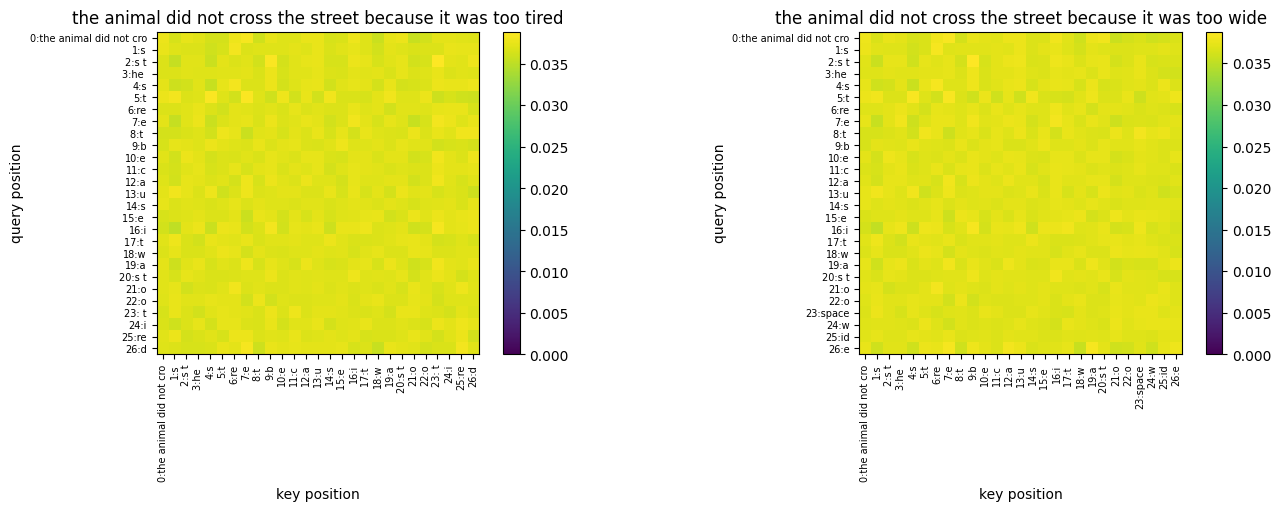

In [5]:
attention_sentences = [
    "the animal did not cross the street because it was too tired",
    "the animal did not cross the street because it was too wide",
]
attention_corpus = "\n".join(attention_sentences)

tokenizer = BPETokenizer()
with contextlib.redirect_stdout(io.StringIO()):
    tokenizer.train(attention_corpus, vocab_size=280)

def token_labels(ids: list[int]) -> list[str]:
    labels = []
    for i, token_id in enumerate(ids):
        piece = tokenizer.decode([int(token_id)]).replace("\n", "\\n")
        if piece == " ":
            piece = "space"
        labels.append(f"{i}:{piece}")
    return labels

embedding_dim = 16
token_embed = TokenEmbedding(vocab_size=len(tokenizer.vocab), embedding_dim=embedding_dim)
pos_embed = LearnedPositionalEmbedding(max_seq_len=128, embedding_dim=embedding_dim)
viz_attn = SelfAttention(embedding_dim=embedding_dim, causal=False)

def sentence_attention(sentence: str) -> tuple[torch.Tensor, list[str]]:
    ids = tokenizer.encode(sentence)
    ids_tensor = torch.tensor(ids, dtype=torch.long).unsqueeze(0)
    x = token_embed(ids_tensor) + pos_embed(ids_tensor.shape[1]).unsqueeze(0)
    weights = viz_attn.attention_weights(x)[0].detach()
    return weights, token_labels(ids)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, sentence in zip(axes, attention_sentences):
    weights, labels = sentence_attention(sentence)
    image = ax.imshow(weights, vmin=0.0, vmax=float(weights.max()), cmap="viridis")
    ax.set_title(sentence)
    ax.set_xlabel("key position")
    ax.set_ylabel("query position")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Exercise 3 - The Strip-Mask Cheat

This experiment uses a sequence-wide language-modeling objective: input positions `0..T-1` predict targets `1..T`. With `causal=False`, position `t` can attend to input position `t+1`, which is exactly the target for that row. With `causal=True`, it cannot. The loss below ignores the final position because its target is outside the input window in both settings; the point is to isolate the rows where future-token leakage exists.

That leakage does **not** show up with Module 06's `train_lm` last-position interface, because the target token is outside the input window. The all-positions setup below is the standard transformer LM training shape where the causal mask is load-bearing.

In [ ]:
"Question: Why does the non-causal model have access to the answer in this setup?"
"Answer: Because it can look forward in the token sequence and see the animals"

"Question: Why would a suspiciously perfect training curve be a red flag in an LM?"
"Answer: Because in reality there is fundamental randomness in language regardless of how good a model is"

In [6]:
class TinySequenceAttentionLM(Module):
    def __init__(self, vocab_size: int, seq_len: int, embedding_dim: int, *, causal: bool) -> None:
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.embedding_dim = embedding_dim
        self.embed = TokenEmbedding(vocab_size, embedding_dim)
        self.pos = LearnedPositionalEmbedding(seq_len, embedding_dim)
        self.attn = SelfAttention(embedding_dim, causal=causal)
        self.out = Linear(embedding_dim, vocab_size)

    def parameters(self):
        return [
            *self.embed.parameters(),
            *self.pos.parameters(),
            *self.attn.parameters(),
            *self.out.parameters(),
        ]

    def forward(self, ids: torch.Tensor) -> torch.Tensor:
        B, T = ids.shape
        x = self.embed(ids) + self.pos(T).unsqueeze(0)
        x = self.attn(x)
        return self.out(x)


def get_sequence_batch(ids: torch.Tensor, seq_len: int, batch_size: int, *, generator=None):
    starts = torch.randint(0, len(ids) - seq_len - 1, (batch_size,), generator=generator)
    x = torch.stack([ids[s : s + seq_len] for s in starts])
    y = torch.stack([ids[s + 1 : s + seq_len + 1] for s in starts])
    return x, y


def sequence_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    # Ignore the last row: its target is not present in the input window.
    logits = logits[:, :-1, :]
    targets = targets[:, :-1]
    return CrossEntropyLoss()(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))


def train_sequence_model(model, ids, *, steps=500, batch_size=128, lr=0.5, log_every=50, seed=0):
    optimizer = SGD(model.parameters(), lr=lr)
    losses = []
    generator = torch.Generator().manual_seed(seed)
    for step in range(steps):
        x, y = get_sequence_batch(ids, model.seq_len, batch_size, generator=generator)
        logits = model(x)
        loss = sequence_loss(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % log_every == 0 or step == steps - 1:
            losses.append(float(loss.item()))
    return losses

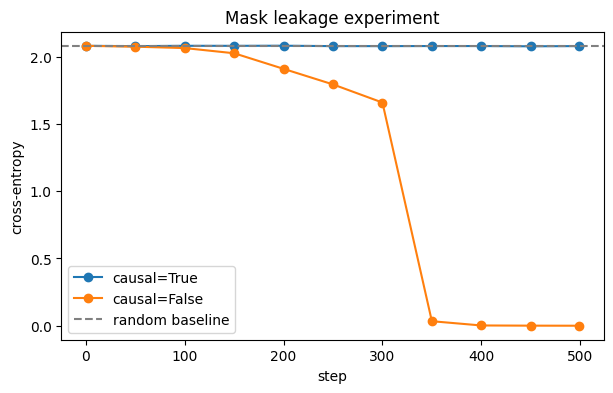

final causal loss: 2.0774295330047607
final non-causal loss: 0.0006712728063575923


In [7]:
random_vocab_size = 8
random_stream = torch.randint(
    0,
    random_vocab_size,
    (4096,),
    generator=torch.Generator().manual_seed(7),
)

strip_seq_len = 8
strip_steps = 500
strip_log_every = 50

causal_lm = TinySequenceAttentionLM(random_vocab_size, strip_seq_len, 32, causal=True)
noncausal_lm = TinySequenceAttentionLM(random_vocab_size, strip_seq_len, 32, causal=False)

causal_losses = train_sequence_model(
    causal_lm,
    random_stream,
    steps=strip_steps,
    log_every=strip_log_every,
    seed=1,
)
noncausal_losses = train_sequence_model(
    noncausal_lm,
    random_stream,
    steps=strip_steps,
    log_every=strip_log_every,
    seed=2,
)

strip_steps_logged = list(range(0, strip_steps, strip_log_every))
if strip_steps_logged[-1] != strip_steps - 1:
    strip_steps_logged.append(strip_steps - 1)

plt.figure(figsize=(7, 4))
plt.plot(strip_steps_logged, causal_losses, marker="o", label="causal=True")
plt.plot(strip_steps_logged, noncausal_losses, marker="o", label="causal=False")
plt.axhline(math.log(random_vocab_size), color="0.5", linestyle="--", label="random baseline")
plt.title("Mask leakage experiment")
plt.xlabel("step")
plt.ylabel("cross-entropy")
plt.legend()
plt.show()

print("final causal loss:", causal_losses[-1])
print("final non-causal loss:", noncausal_losses[-1])

## Exercise 4 - Parameter Count

The attention layer has four `Linear(D, D)` projections: Q, K, V, and output. That means the parameter count is `4 * (D * D + D)` and does not depend on sequence length.

In [ ]:
"Question: Why does the parameter count not depend on T?"
"Answer: Because increasing T doesn't mean there are more parameters to fit, it means the existing weight matrices are applied over more tokens in the context window"

"Question: If parameters do not grow with T, what part of attention still gets expensive as T grows?"
"Answer: Because the Q, K, V weight matrices need to be repeated on every token prior to the current token."

In [8]:
print("D    expected    actual")
print("-" * 28)
for D in [64, 128, 256, 512]:
    attn = SelfAttention(embedding_dim=D)
    expected = 4 * (D * D + D)
    actual = sum(p.numel() for p in attn.parameters())
    print(f"{D:<4d} {expected:<10d} {actual:<10d}")
    assert expected == actual

D    expected    actual
----------------------------
64   16640      16640     
128  66048      66048     
256  263168     263168    
512  1050624    1050624   


## Exercise 5 - Feel the Quadratic Cost

The score tensor is shaped `(B, T, T)`. This timing cell keeps `D` fixed and increases `T`. The default sizes are conservative for a notebook; add larger values if your machine is comfortable.

In [11]:
"Question: Why should a log-log time plot bend toward slope 2 as T grows?"
"Answer: Because the cost of increased K, V, Q computation is O(T^2). Linear in terms of every token has to look at every previous token so it scales with T/2, then linear in that you have to repeat for every token, another T scale factor"

"Question: Why might small T values not show a clean quadratic trend?"
"Answer: Because there evaluation time is dominated by other components of the pass, like the feed forward network. "

'Answer: Because there evaluation time is dominated by other components of the pass, like the feed forward network. '

T=64    seconds=0.00031
T=128   seconds=0.00034
T=256   seconds=0.00057
T=512   seconds=0.00164


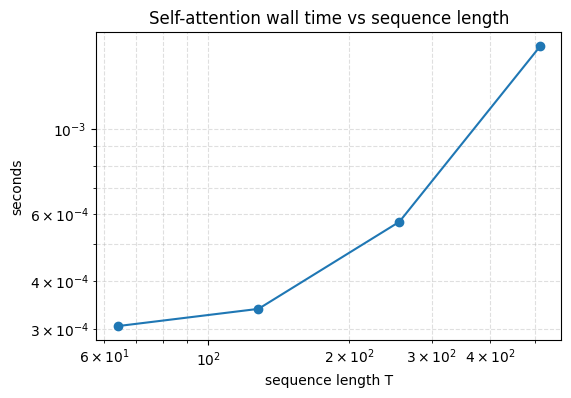

In [12]:
timing_attn = SelfAttention(embedding_dim=128, causal=True)
timing_lengths = [64, 128, 256, 512]
timing_seconds = []

for T in timing_lengths:
    x = torch.randn(1, T, 128)
    _ = timing_attn(x)
    start = time.perf_counter()
    with torch.no_grad():
        _ = timing_attn(x)
    elapsed = time.perf_counter() - start
    timing_seconds.append(elapsed)
    print(f"T={T:<5d} seconds={elapsed:.5f}")

plt.figure(figsize=(6, 4))
plt.loglog(timing_lengths, timing_seconds, marker="o")
plt.title("Self-attention wall time vs sequence length")
plt.xlabel("sequence length T")
plt.ylabel("seconds")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()